In [2]:
from pathlib import Path
from dataclasses import dataclass
from PIL import Image

import tyro

import torch
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset

from torchvision import transforms
from torchvision.transforms import v2, functional as VF
from torchvision.io import write_png

import pytorch_lightning as pl
from transformers import SegformerConfig, SegformerForSemanticSegmentation

from matplotlib import pyplot as plt


In [ ]:
class UnwrapperDataset(Dataset):
    def __init__(
        self,
        root: str,
        images_name: str,
        masks_name: str,
        size: int = 512,
        do_augmentations: bool = False,
    ):
        self.root = Path(root)
        self.images_name = images_name
        self.masks_name = masks_name
        self.size = size
        self.do_augmentations = do_augmentations

        self.transform = v2.Compose(
            [
                v2.Resize(
                    (self.size, self.size),
                    interpolation=transforms.InterpolationMode.BICUBIC,
                ),
                v2.ToTensor(),
            ]
        )
        if self.do_augmentations:
            self.transform = v2.Compose(
                [
                    v2.RandomAffine(
                        degrees=10,
                        scale=(0.8, 1.2),
                        shear=10,
                        interpolation=transforms.InterpolationMode.BICUBIC,
                    ),
                    v2.RandomHorizontalFlip(),
                    v2.RandomVerticalFlip(),
                    self.transform,
                ]
            )

        self.data = []
        img_dir = self.root / self.images_name
        masks_dir = self.root / self.masks_name

        for image_path in img_dir.iterdir():
            image_name = image_path.name
            mask_path = masks_dir / image_name

            if image_path.exists() and mask_path.exists():
                self.data.append((str(image_path), str(mask_path)))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx: int):
        image_path, mask_path = self.data[idx]

        image = Image.open(image_path)
        mask = Image.open(mask_path)

        image, mask = self.transform(image, mask)

        return image, mask

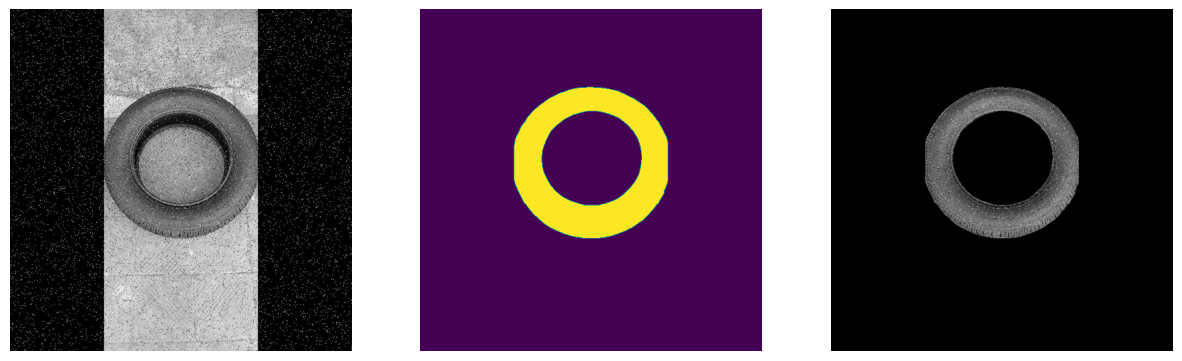

In [36]:
from matplotlib import axes


dataset = UnwrapperDataset(
    "/Users/n-zagainov/kolobok/ml/data/sidewall/train_processed",
    "images",
    "masks",
    size=512,
    do_augmentations=False,
)

img, mask = dataset[32]

fig, ax = plt.subplots(1, 3, figsize=(15, 7))
ax[0].imshow(img.permute(1, 2, 0))
ax[1].imshow(mask[0])
ax[2].imshow((img * mask).permute(1, 2, 0))

for a in ax:
    a.axis("off")

plt.show()